In [2]:
suppressMessages(library(ggplot2))
suppressMessages(library(tidyr))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(Seurat))
suppressMessages(library(reshape))
suppressMessages(library(readxl))
suppressMessages(library(edgeR))

In [7]:
part1 <- readRDS("bulk_part1.rds")
part2 <- readRDS("bulk_part2.rds")

In [8]:
meta1 <- read_excel("Clinical_Information.xlsx")
meta2 <- read_excel("Clinical_part2.xlsx")

In [9]:
meta1 <- as.data.frame(meta1)
meta2 <- as.data.frame(meta2)

In [10]:
rownames(meta1) <- meta1$sample
rownames(meta2) <- meta2$Samples

In [11]:
meta1[1] <- NULL
meta1[1] <- NULL
meta2[1] <- NULL
meta2[1] <- NULL

In [12]:
meta1$Treatment <- "Unknown"
meta2$Primary_Recurrent <- "Unknown"

In [13]:
meta2 <- meta2[,c(1,2,3,5,4)]

In [14]:
meta1$batch <- "first"
meta2$batch <- "second"

In [15]:
meta <- rbind(meta1,meta2)

In [16]:
counts <- cbind(part1,part2)

In [17]:
bulk_brca1 <- CreateSeuratObject(counts, project = "bulk_brca1", assay = "RNA",
  min.cells = 0, min.features = 0, names.field = 1,
  names.delim = "_", meta.data = meta)
bulk_brca1

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”


An object of class Seurat 
35479 features across 73 samples within 1 assay 
Active assay: RNA (35479 features, 0 variable features)
 1 layer present: counts

In [18]:
tnbc1 <- read.csv("TNBC_subtypes.csv", row.names = 1)
tnbc2 <- read.csv("no_ESR1_TNBC_subtypes.csv", row.names = 1)

In [19]:
tnbc <- rbind(tnbc1,tnbc2)

In [20]:
bulk_brca1 <- AddMetaData(bulk_brca1, tnbc)

In [21]:
metadata <- bulk_brca1@meta.data %>% replace_na(list(subtype = 'not_typed'))
bulk_brca1@meta.data <- metadata

In [22]:
saveRDS(bulk_brca1, "full_bulk_brca1_seurat5.rds")

In [3]:
bulk_brca1 <- readRDS("full_bulk_brca1_seurat5.rds")

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


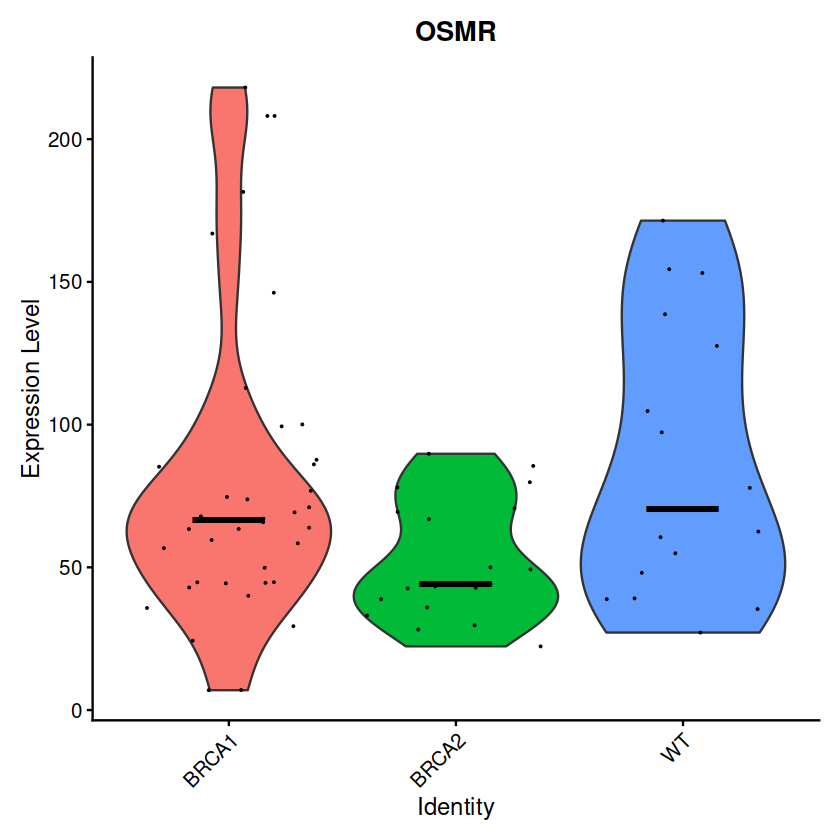

In [4]:
VlnPlot(bulk_brca1, "OSMR", group.by="Mutation")+ stat_summary(fun = median, geom='point', size = 25, colour = "black", shape = 95)+NoLegend()

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


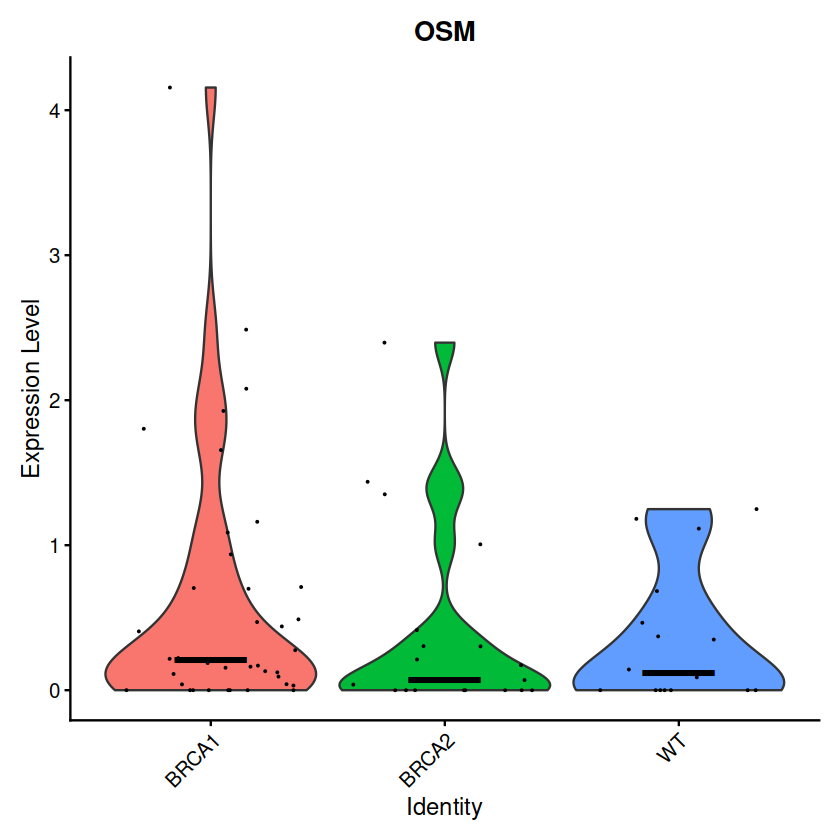

In [5]:
VlnPlot(bulk_brca1, "OSM", group.by="Mutation")+ stat_summary(fun = median, geom='point', size = 25, colour = "black", shape = 95)+NoLegend()

In [28]:
sub <- subset(bulk_brca1, subset = Receptor == "TNBC")
sub <- subset(sub, subset = Mutation == "BRCA2", invert = T)

In [35]:
er_sus_pt <- c("Brca1Br44_kallisto", "TNBC_BRCA1_23", "TNBC_BRCA1_29", "TNBC_BRCA1_33", "TNBC_WT_36", "TNBC_WT_52", "TNBC_BRCA2_59")

In [36]:
sub$patient <- colnames(sub)

In [37]:
er_sus <- subset(sub, subset = patient %in% er_sus_pt)
sub <- subset(sub, subset = patient %in% er_sus_pt, invert = T)

In [27]:
sub <-NormalizeData(sub)

Normalizing layer: counts



In [28]:
tnbc <- sub[["RNA"]]$data
tnbc <- as.data.frame(tnbc)

In [29]:
dge <- DGEList(counts=tnbc)
dge <- calcNormFactors(dge, method = "TMM")
norm_counts <- cpm(dge)

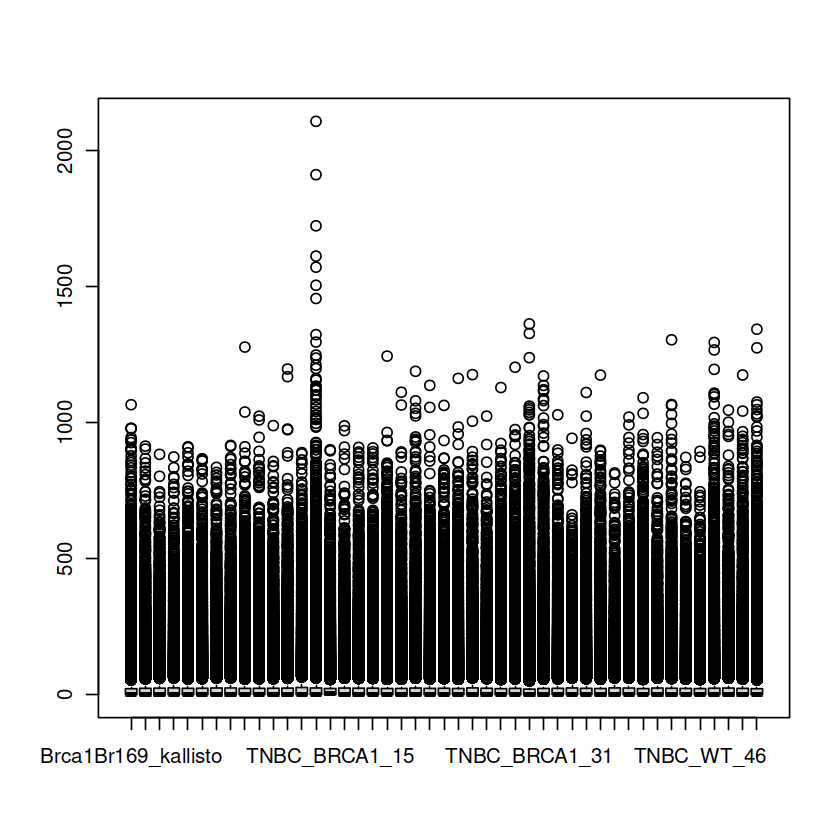

In [30]:
boxplot(norm_counts)

In [31]:
write.csv(norm_counts, "norm_counts_for_subtyping_tnbc.csv")

Normalizing layer: counts



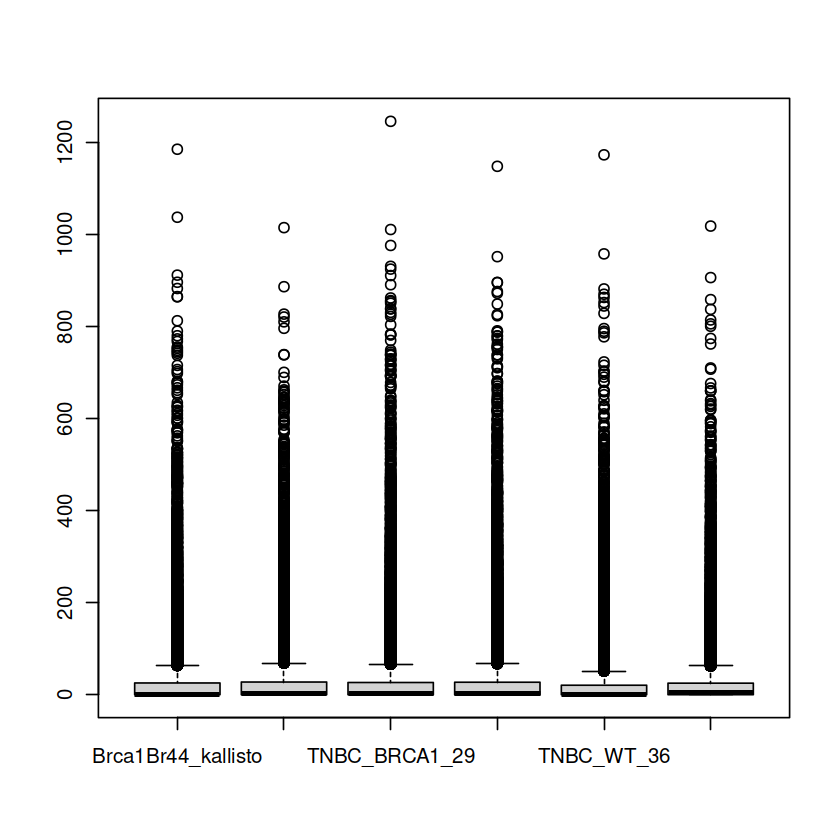

In [38]:
er_sus[["RNA"]]$counts["ESR1",] <- 0 

er_sus <-NormalizeData(er_sus)

tnbc <- er_sus[["RNA"]]$data
tnbc <- as.data.frame(tnbc)

dge <- DGEList(counts=tnbc)
dge <- calcNormFactors(dge, method = "TMM")
norm_counts <- cpm(dge)

boxplot(norm_counts)

In [40]:
write.csv(norm_counts, "er_sus_no ESR1_norm_counts_for_subtyping_tnbc.csv")

In [17]:
norm_counts[which(rownames(norm_counts)=="ESR1"),]

Brca1Br169_kallisto Brca1Br170_kallisto Brca1Br121_kallisto Brca1Br122_kallisto 
        17.25333878         15.14754463          6.77151389          6.37155175 
Brca1Br142_kallisto  Brca1Br28_kallisto Brca1Br123_kallisto Brca1Br125_kallisto 
         2.51430791          6.57414179          4.57538547          2.19410455 
Brca1Br128_kallisto  Brca1Br29_kallisto Brca1Br126_kallisto Brca1Br159_kallisto 
         0.51078177          0.00000000          1.08249506          0.13437608 
Brca1Br168_kallisto  Brca2Br84_kallisto Brca2Br101_kallisto Brca2Br102_kallisto 
         3.79680269          8.51118924          4.73999684          6.20680615 
 Brca1Br44_kallisto       TNBC_BRCA1_15       TNBC_BRCA1_16       TNBC_BRCA1_17 
        41.62044644          7.62956686          3.87363488          4.90633964 
      TNBC_BRCA1_18       TNBC_BRCA1_19       TNBC_BRCA1_20       TNBC_BRCA1_21 
         4.70724995          1.96270472          0.82630598          5.98279155 
      TNBC_BRCA1_22       TNBC_BRCA1_23       TNBC_BRCA1_24       TNBC_BRCA1_25 
         1.34986461         26.70111704          4.90187117         16.80655882 
      TNBC_BRCA1_26       TNBC_BRCA1_27       TNBC_BRCA1_28       TNBC_BRCA1_29 
        15.28988615          5.02047465          8.57096703         45.70446861 
      TNBC_BRCA1_30       TNBC_BRCA1_31       TNBC_BRCA1_33       TNBC_BRCA1_34 
         6.39366474          5.65955442        117.66536749          9.94756390 
      TNBC_BRCA1_35          TNBC_WT_36          TNBC_WT_37          TNBC_WT_38 
         4.90458023         45.40753988          0.00000000          3.03658070 
         TNBC_WT_39          TNBC_WT_40          TNBC_WT_41          TNBC_WT_42 
         3.48912812          6.31120868         11.05967337          1.67840127 
         TNBC_WT_43          TNBC_WT_44          TNBC_WT_45          TNBC_WT_46 
         4.53611009          2.22517317          0.20962807          0.32874032 
         TNBC_WT_47          TNBC_WT_48          TNBC_WT_49          TNBC_WT_50 
         6.70047300         13.45440609          1.56813762          3.97236665 
         TNBC_WT_52       TNBC_BRCA2_53       TNBC_BRCA2_54       TNBC_BRCA2_55 
        30.13632675          0.46840846          4.94425802          0.29791729 
      TNBC_BRCA2_56       TNBC_BRCA2_57       TNBC_BRCA2_58       TNBC_BRCA2_59 
         8.42398786          1.16382162          8.45220516        147.75490972 
      TNBC_BRCA2_60 
         0.04225826

In [49]:
sub <- subset(bulk_brca1, subset = Mutation == "BRCA2", invert = T)
sub <- subset(sub, subset = Group == "Tumor")
sub <- subset(sub, subset = Receptor == "TNBC")
#sub <- subset(sub, subset = subtype %in% c("BL1","BL2","LAR","M"))

In [29]:
saveRDS(sub, "bulk_brca1_seurat5_final.rds")

In [30]:
table(sub$Mutation)


BRCA1    WT 
   35    16 

In [114]:
saveRDS(bulk_brca1, "bulk_brca1_seurat5.rds")

In [3]:
bulk_brca1 <- readRDS("bulk_brca1_seurat5_final.rds")

In [4]:
bulk_brca1

An object of class Seurat 
35479 features across 51 samples within 1 assay 
Active assay: RNA (35479 features, 0 variable features)
 2 layers present: counts, data

In [8]:
bulk_brca1_only <- subset(bulk_brca1, subset = Mutation == "BRCA1")

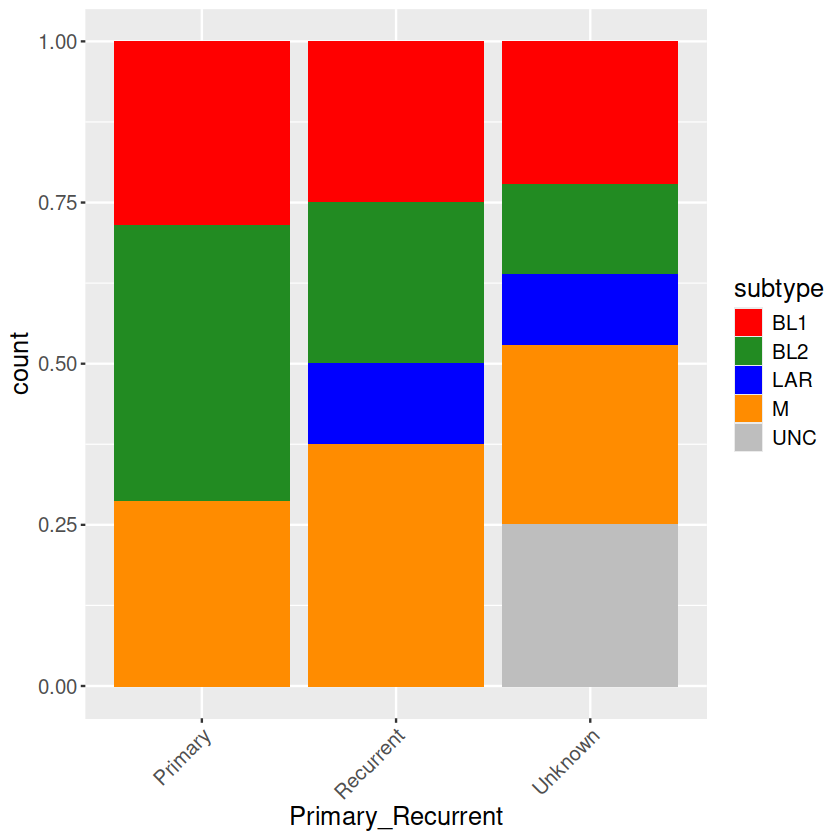

In [23]:
#pdf("primary_recurrent_by_subtype_stacked_bar.pdf")

ggplot(bulk_brca1@meta.data, aes(x=Primary_Recurrent,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","blue","darkorange","grey"))

#dev.off()

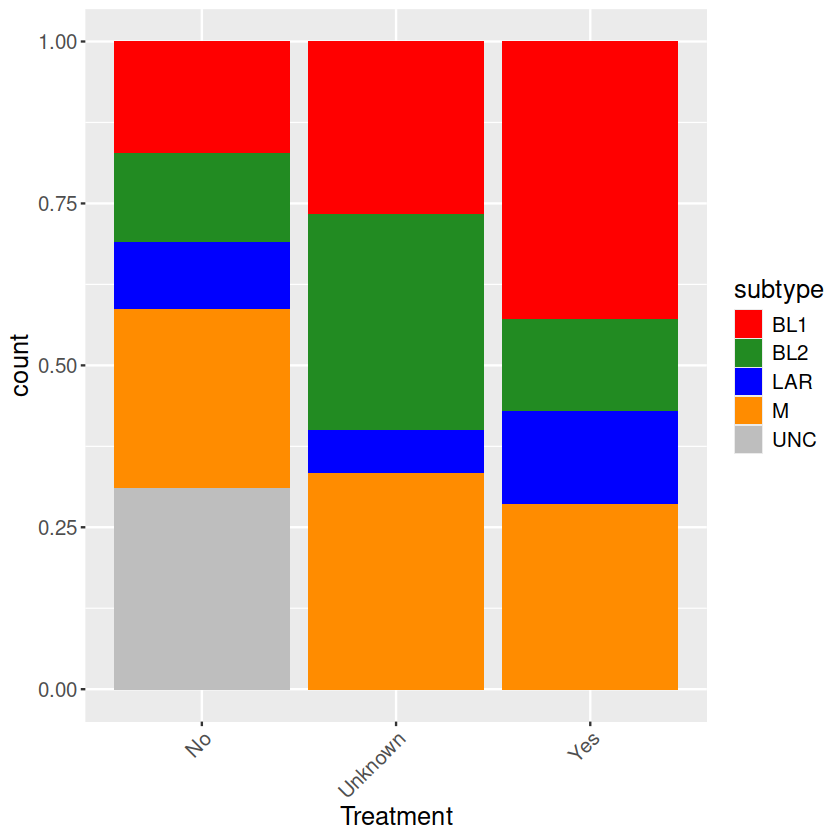

In [25]:
#pdf("treatment_by_subtype_stacked_bar.pdf")

ggplot(bulk_brca1@meta.data, aes(x=Treatment,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","blue","darkorange","grey"))

#dev.off()

In [17]:
table(bulk_brca1$Treatment,bulk_brca1$subtype)

         
          BL1 BL2 LAR M UNC
  No        5   4   3 8   9
  Unknown   4   5   1 5   0
  Yes       3   1   1 2   0

In [18]:
table(bulk_brca1$Primary_Recurrent,bulk_brca1$subtype)

           
            BL1 BL2 LAR  M UNC
  Primary     2   3   0  2   0
  Recurrent   2   2   1  3   0
  Unknown     8   5   4 10   9

# no BRCA2

In [21]:
sub <- subset(sub, subset = Mutation == "BRCA2", invert = T)

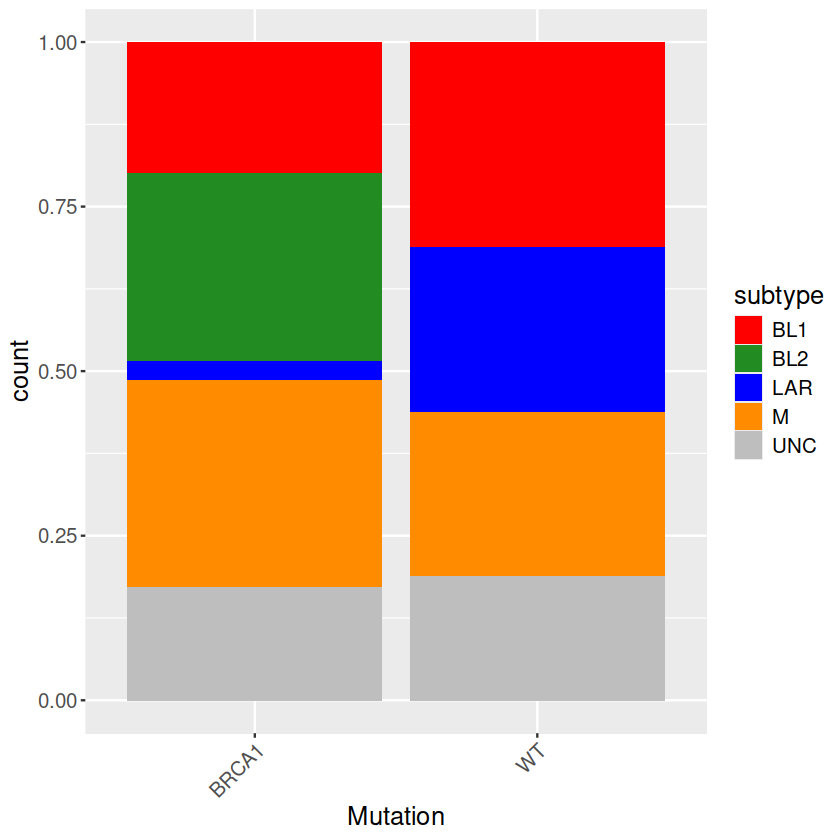

In [8]:
#pdf("mutation_by_subtype_stacked_bar.pdf")

ggplot(bulk_brca1@meta.data, aes(x=Mutation,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","blue","darkorange","grey"))
#dev.off()

# all tumors

In [5]:
sub

An object of class Seurat 
35479 features across 70 samples within 1 assay 
Active assay: RNA (35479 features, 0 variable features)
 1 layer present: counts

In [14]:
table(bulk_brca1$Group)
table(sub$Receptor)
table(sub$Mutation)


Normal Normal         Tumor 
            3            70 


 HR+ TNBC 
   9   61 


BRCA1 BRCA2    WT 
   36    18    16 

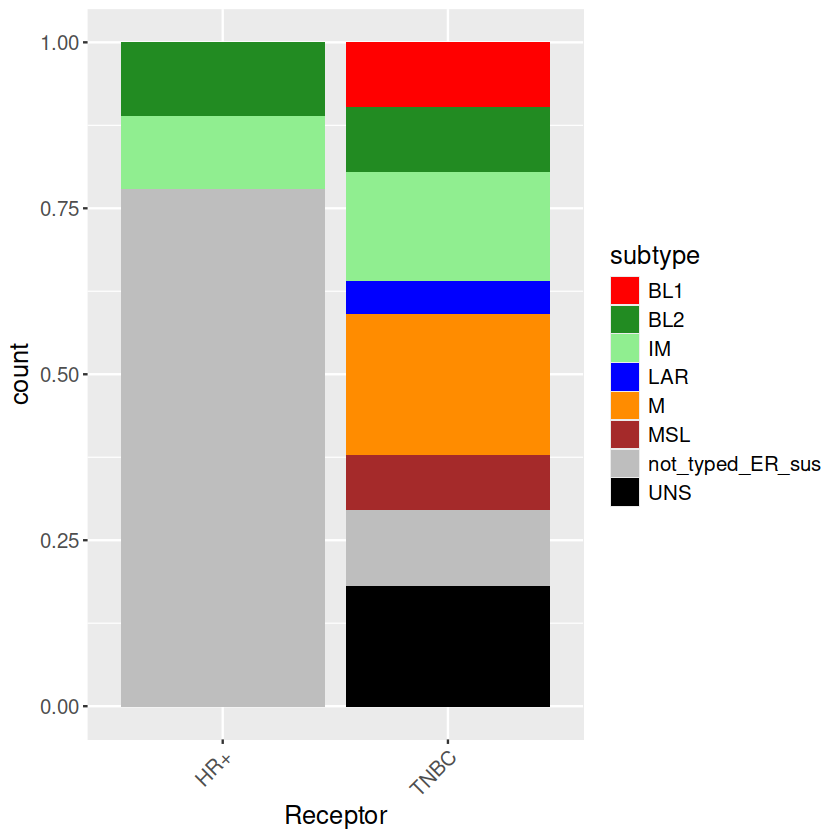

In [11]:
ggplot(sub@meta.data, aes(x=Receptor,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


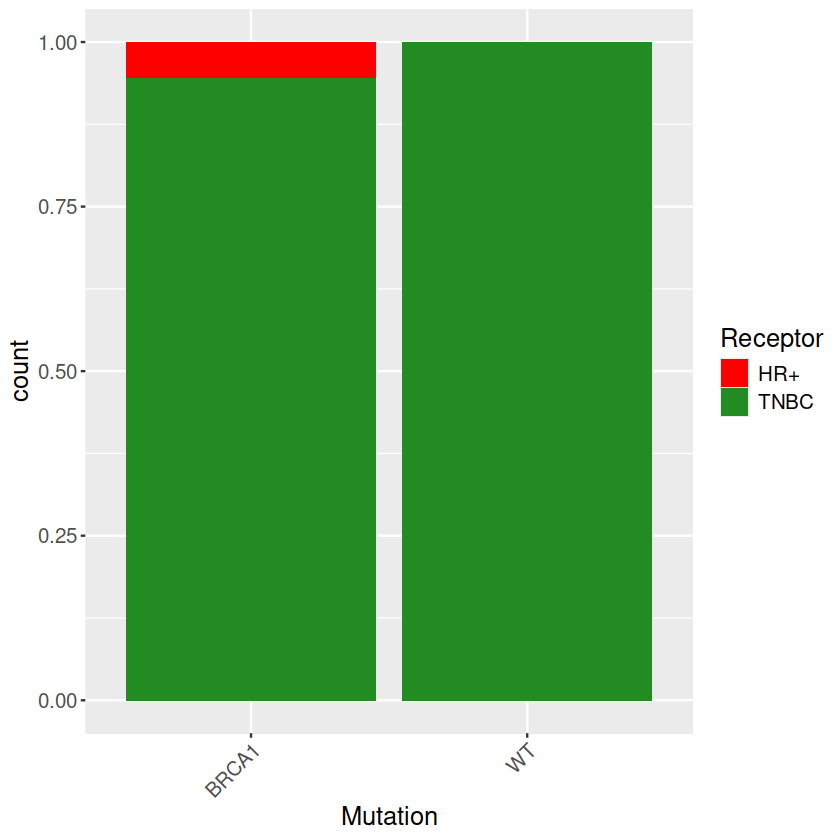

In [22]:
ggplot(sub@meta.data, aes(x=Mutation,
                          fill=Receptor)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


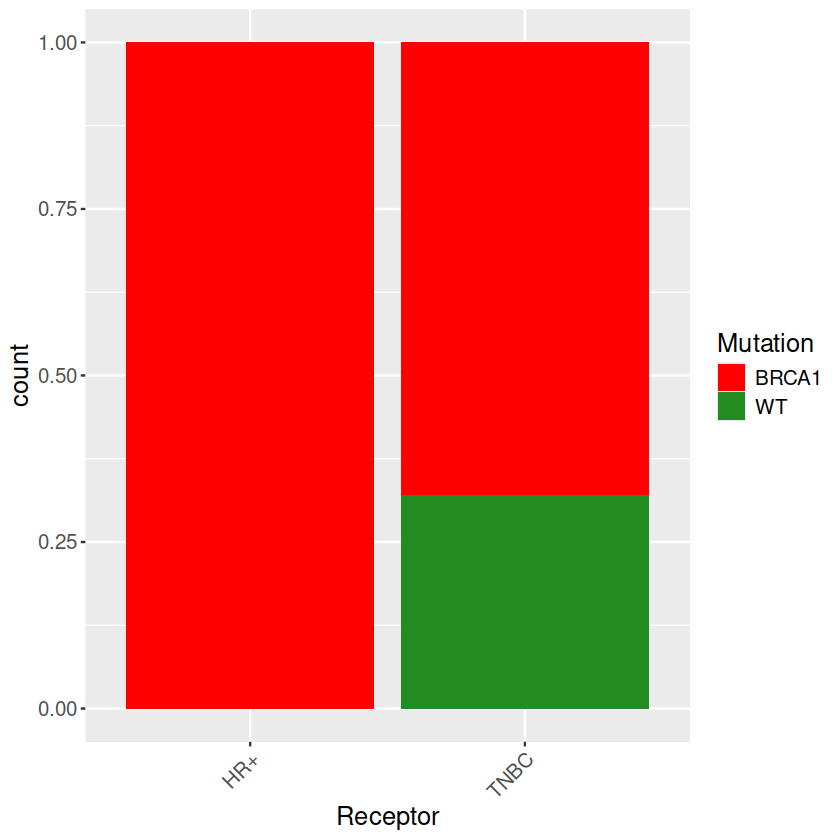

In [23]:
ggplot(sub@meta.data, aes(x=Receptor,
                          fill=Mutation)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


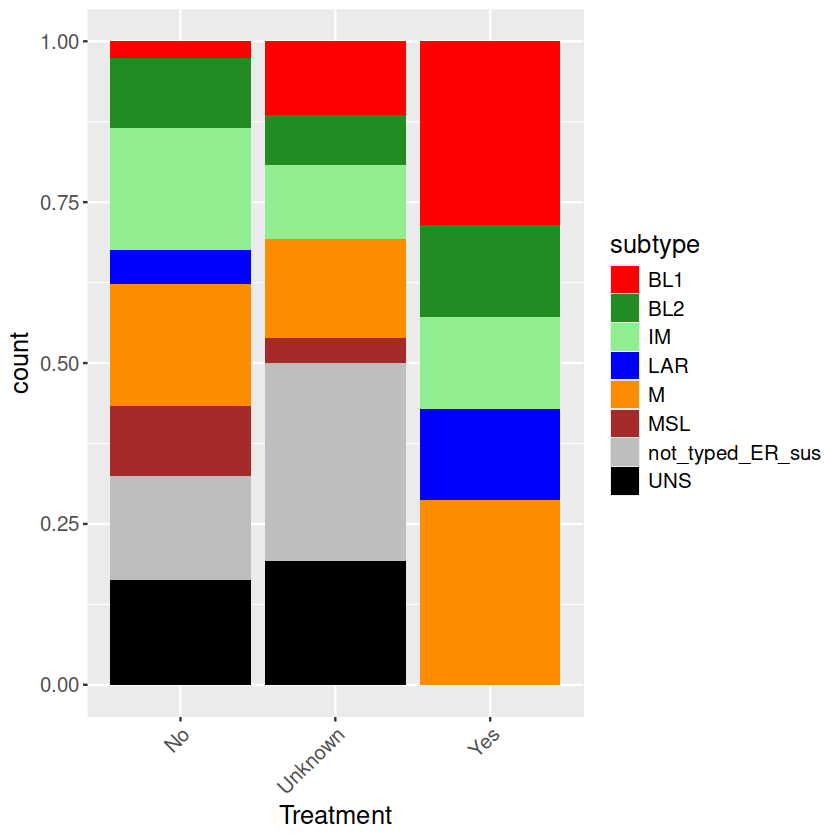

In [15]:
ggplot(sub@meta.data, aes(x=Treatment,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


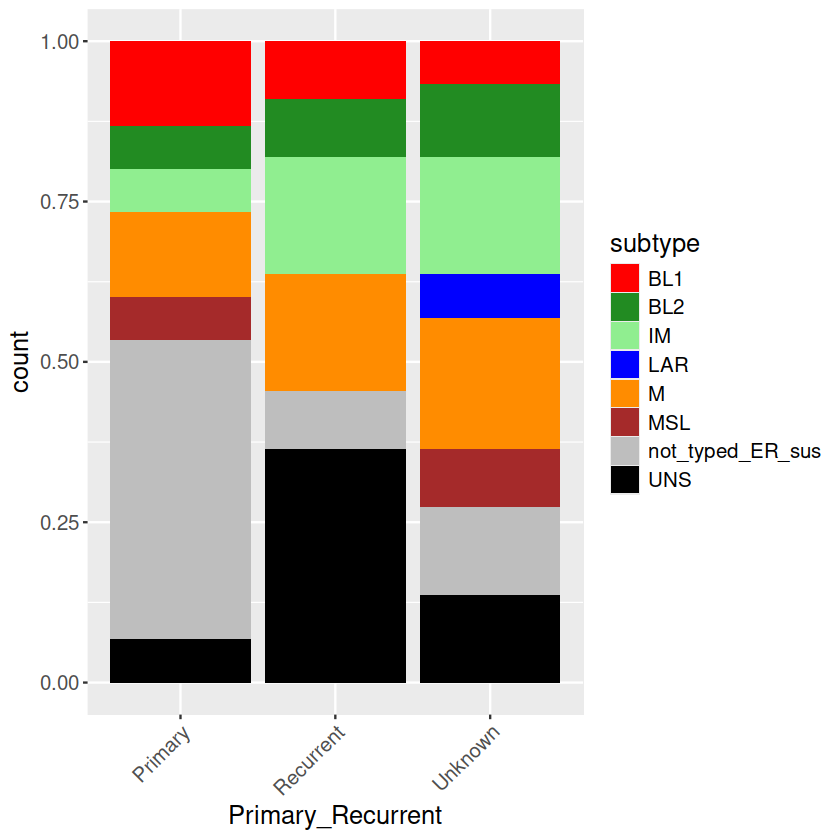

In [16]:
ggplot(sub@meta.data, aes(x=Primary_Recurrent,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


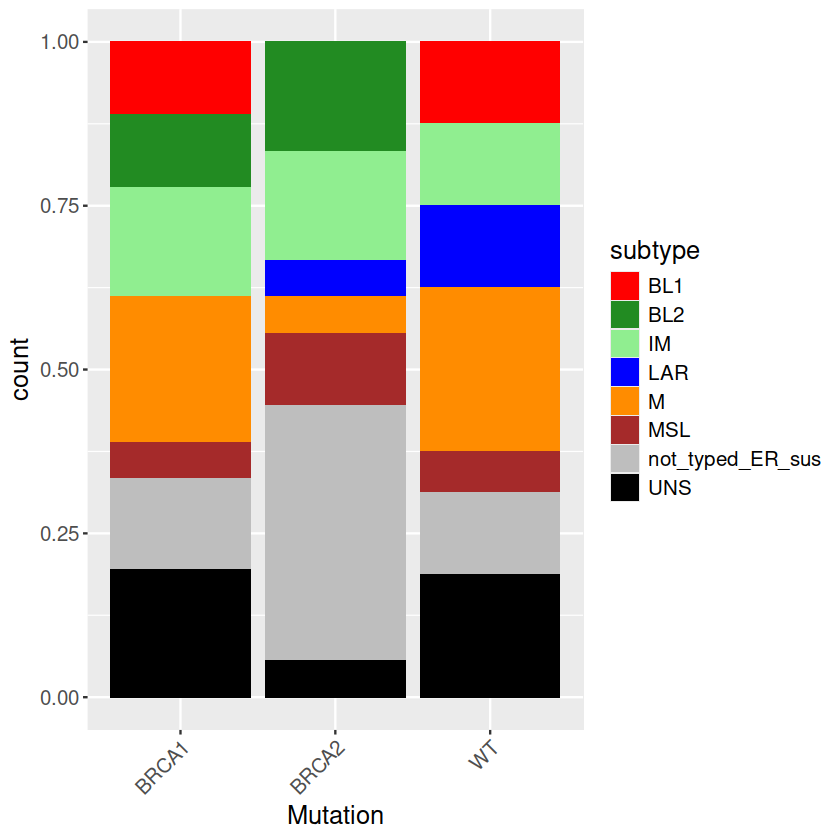

In [17]:
ggplot(sub@meta.data, aes(x=Mutation,
                          fill=subtype)) + 
geom_bar(position = "fill")+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


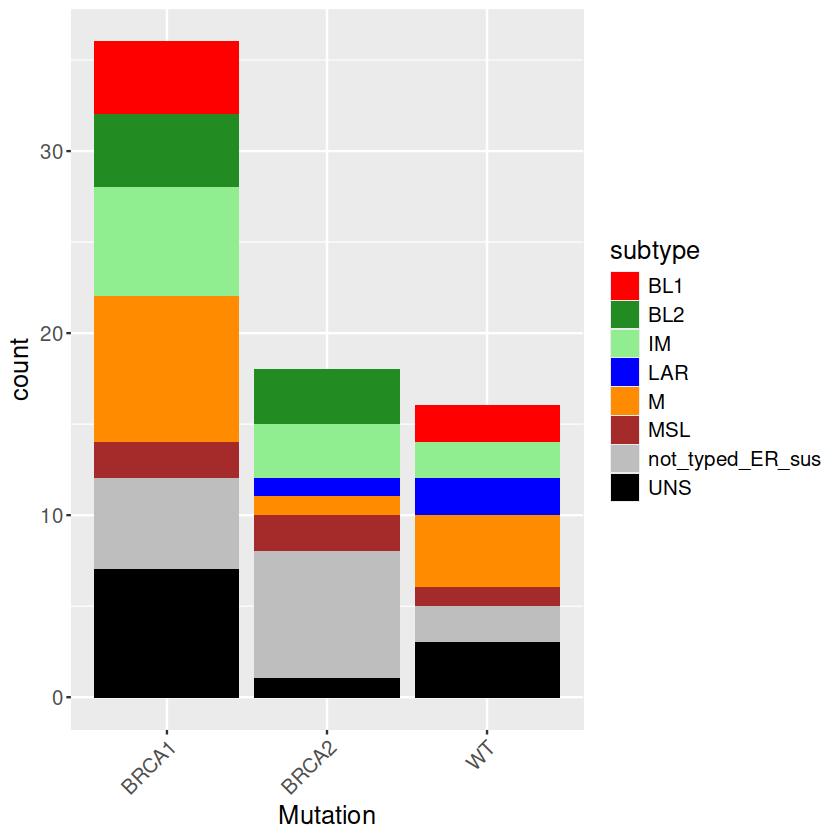

In [18]:
ggplot(sub@meta.data, aes(x=Mutation,
                          fill=subtype)) + 
geom_bar()+ 
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+ 
theme(text=element_text(size=15))+ 
theme(text=element_text(size=15))+ scale_fill_manual(values=c("red","forestgreen","lightgreen","blue","darkorange","brown","grey","black"))


In [22]:
tnbc <- subset(sub, subset = subtype %in% c("BL1","BL2","IM","LAR","M","MSL","UNS"))

In [25]:
meta <- tnbc@meta.data[,c("Group","Receptor","Mutation","Primary_Recurrent","Treatment","batch","subtype","correlation","p.value")]

In [27]:
write.csv(meta, "tumor_subtypes_bulkRNAseq_NathansonLab.csv")

In [133]:
sub <- NormalizeData(object = sub, normalization.method = "LogNormalize", 
    scale.factor = 10000)

Normalizing layer: counts

